# Statistical Analysis: Olist Customer Churn

This notebook performs rigorous statistical testing to validate hypotheses from EDA and quantify the strength and significance of relationships between features and churn.

**Analysis Structure:**
1. Data Loading & Preparation
2. Continuous Variables — T-tests + Mann-Whitney U + Effect Sizes (Cohen's d)
3. Categorical Variables — Chi-square Tests + Effect Sizes (Cramér's V)
4. Multicollinearity Check (VIF)
5. Correlation Analysis
6. Logistic Regression + Odds Ratios
7. Summary of Findings

## 1. Setup & Data Loading

In [19]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy statsmodels --quiet

1203.54s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.13 -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, ttest_ind
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✓ Libraries loaded')

✓ Libraries loaded


In [21]:
data_path = Path('../data/processed/olist_churn_master.csv')
df = pd.read_csv(data_path)

print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nChurn Distribution:')
churn_counts = df['churn'].value_counts()
for val, cnt in churn_counts.items():
    label = 'Churned' if val == 1 else 'Retained'
    print(f'  {label} ({val}): {cnt:,} ({cnt/len(df)*100:.1f}%)')

churned = df[df['churn'] == 1]
retained = df[df['churn'] == 0]
print(f'\n✓ Data loaded successfully')

Dataset Shape: 105,000 rows × 19 columns

Churn Distribution:
  Churned (1): 97,549 (92.9%)
  Retained (0): 7,451 (7.1%)

✓ Data loaded successfully


## 2. Helper Functions

We define reusable functions for effect size calculations to ensure consistency throughout the notebook.

In [22]:
def cohens_d(group1, group2):
    """Cohen's d: standardised effect size for two independent groups."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

def cramers_v(contingency_table):
    """Cramér's V: effect size for chi-square tests."""
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.2: return 'Negligible'
    elif d < 0.5: return 'Small'
    elif d < 0.8: return 'Medium'
    else: return 'Large'

def interpret_cramers_v(v):
    if v < 0.1: return 'Negligible'
    elif v < 0.3: return 'Small'
    elif v < 0.5: return 'Medium'
    else: return 'Large'

print('✓ Helper functions defined')

✓ Helper functions defined


## 3. Continuous Variables: T-tests, Mann-Whitney U & Effect Sizes

For each continuous variable, we run:
- **Welch's T-test** — tests for a difference in means (robust to unequal variances)
- **Mann-Whitney U** — non-parametric test; better for skewed/non-normal distributions
- **Cohen's d** — standardised effect size (not influenced by sample size)

> ⚠️ With 100K+ records, almost any difference will be statistically significant (p < 0.05). Effect size tells us if it's *practically* meaningful.

### 3.1 Delivery Delay vs. Churn

**H₀:** No significant difference in average delivery delay between churned and retained customers.  
**H₁:** Churned customers experience significantly higher average delivery delays.

In [23]:
delay_data = df.dropna(subset=['delivery_delay_days', 'churn'])
churned_delay   = delay_data[delay_data['churn'] == 1]['delivery_delay_days']
retained_delay  = delay_data[delay_data['churn'] == 0]['delivery_delay_days']

t_stat, p_ttest  = ttest_ind(churned_delay, retained_delay, equal_var=False)
u_stat, p_mannwh = mannwhitneyu(churned_delay, retained_delay, alternative='two-sided')
d = cohens_d(churned_delay, retained_delay)

print('=== Delivery Delay vs. Churn ===')
print(f'  Mean delay — Churned:   {churned_delay.mean():.2f} days  (std: {churned_delay.std():.2f})')
print(f'  Mean delay — Retained:  {retained_delay.mean():.2f} days  (std: {retained_delay.std():.2f})')
print(f'\n  Welch T-test:     t = {t_stat:.4f},  p = {p_ttest:.4e}')
print(f'  Mann-Whitney U:   U = {u_stat:.0f},  p = {p_mannwh:.4e}')
print(f'\n  Cohen\'s d:  {d:.4f}  → {interpret_cohens_d(d)} effect')
print()
decision = 'REJECT H₀' if p_ttest < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision ({"α=0.05"}): {decision}')

=== Delivery Delay vs. Churn ===
  Mean delay — Churned:   -11.97 days  (std: 10.18)
  Mean delay — Retained:  -12.94 days  (std: 9.80)

  Welch T-test:     t = 8.2012,  p = 2.7190e-16
  Mann-Whitney U:   U = 381676101,  p = 4.2882e-13

  Cohen's d:  0.0954  → Negligible effect

  Decision (α=0.05): REJECT H₀


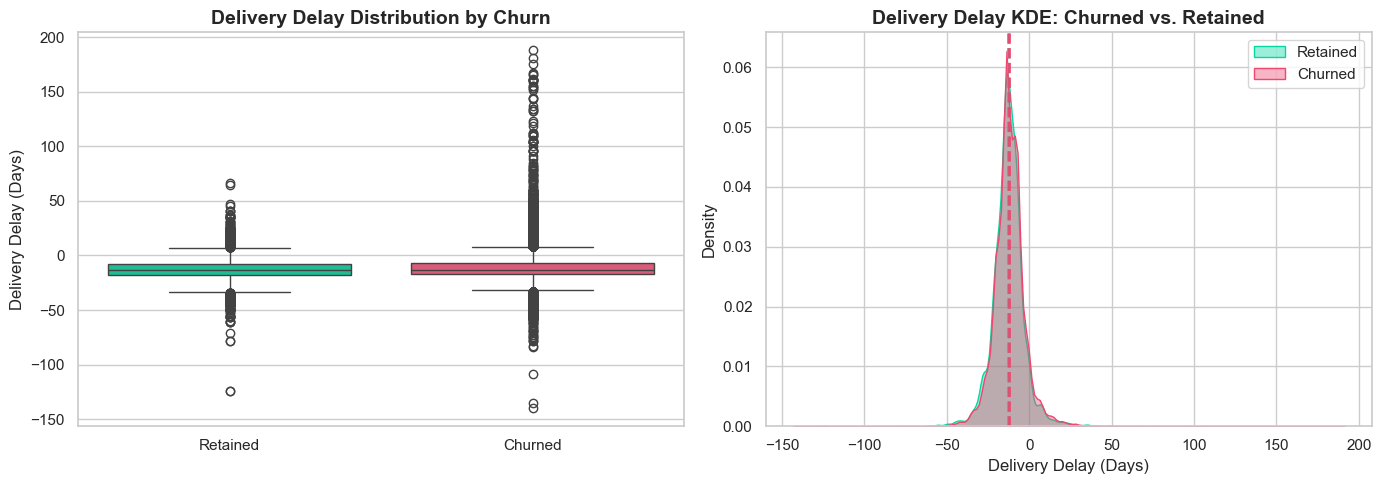

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
plot_df = delay_data[['delivery_delay_days', 'churn']].copy()
plot_df['Churn Label'] = plot_df['churn'].map({0: 'Retained', 1: 'Churned'})
sns.boxplot(data=plot_df, x='Churn Label', y='delivery_delay_days',
            palette={'Retained': '#06d6a0', 'Churned': '#ef476f'}, ax=axes[0])
axes[0].set_title('Delivery Delay Distribution by Churn')
axes[0].set_xlabel('')
axes[0].set_ylabel('Delivery Delay (Days)')

# KDE
sns.kdeplot(retained_delay, label='Retained', color='#06d6a0', fill=True, alpha=0.4, ax=axes[1])
sns.kdeplot(churned_delay,  label='Churned',  color='#ef476f', fill=True, alpha=0.4, ax=axes[1])
axes[1].axvline(retained_delay.mean(), color='#06d6a0', linestyle='--', lw=2)
axes[1].axvline(churned_delay.mean(),  color='#ef476f', linestyle='--', lw=2)
axes[1].set_title('Delivery Delay KDE: Churned vs. Retained')
axes[1].set_xlabel('Delivery Delay (Days)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Review Score vs. Churn

**H₀:** No significant difference in average review score between churned and retained customers.  
**H₁:** Retained customers give significantly higher average review scores.

In [25]:
review_data = df.dropna(subset=['review_score', 'churn'])
churned_review   = review_data[review_data['churn'] == 1]['review_score']
retained_review  = review_data[review_data['churn'] == 0]['review_score']

t_stat, p_ttest  = ttest_ind(churned_review, retained_review, equal_var=False)
u_stat, p_mannwh = mannwhitneyu(retained_review, churned_review, alternative='greater')
d = cohens_d(retained_review, churned_review)

print('=== Review Score vs. Churn ===')
print(f'  Mean score — Churned:   {churned_review.mean():.3f}  (std: {churned_review.std():.3f})')
print(f'  Mean score — Retained:  {retained_review.mean():.3f}  (std: {retained_review.std():.3f})')
print(f'\n  Welch T-test:     t = {t_stat:.4f},  p = {p_ttest:.4e}')
print(f'  Mann-Whitney U:   U = {u_stat:.0f},  p = {p_mannwh:.4e}')
print(f'\n  Cohen\'s d:  {d:.4f}  → {interpret_cohens_d(d)} effect')
print()
decision = 'REJECT H₀' if p_ttest < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05): {decision}')

=== Review Score vs. Churn ===
  Mean score — Churned:   4.077  (std: 1.349)
  Mean score — Retained:  4.128  (std: 1.334)

  Welch T-test:     t = -3.1991,  p = 1.3835e-03
  Mann-Whitney U:   U = 367169732,  p = 4.5513e-06

  Cohen's d:  0.0383  → Negligible effect

  Decision (α=0.05): REJECT H₀


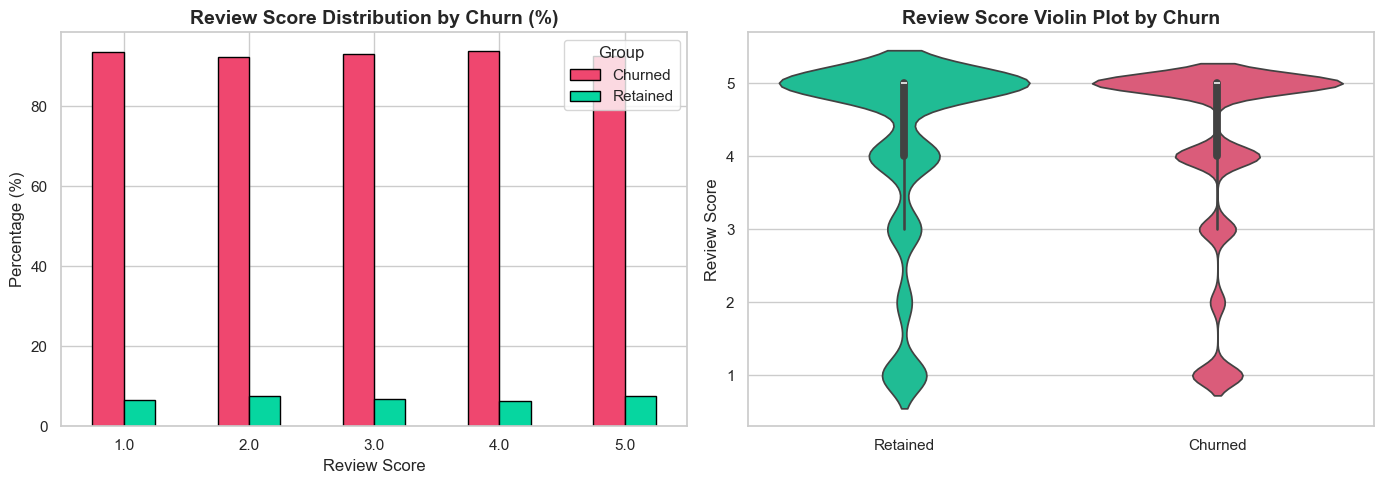

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = review_data[['review_score', 'churn']].copy()
plot_df['Churn Label'] = plot_df['churn'].map({0: 'Retained', 1: 'Churned'})

# Grouped bar
review_dist = plot_df.groupby(['review_score', 'Churn Label']).size().unstack(fill_value=0)
review_dist_pct = review_dist.div(review_dist.sum(axis=1), axis=0) * 100
review_dist_pct.plot(kind='bar', color=['#ef476f', '#06d6a0'], edgecolor='black', ax=axes[0])
axes[0].set_title('Review Score Distribution by Churn (%)')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Group')

# Violin
sns.violinplot(data=plot_df, x='Churn Label', y='review_score',
               palette={'Retained': '#06d6a0', 'Churned': '#ef476f'},
               inner='box', ax=axes[1])
axes[1].set_title('Review Score Violin Plot by Churn')
axes[1].set_xlabel('')
axes[1].set_ylabel('Review Score')

plt.tight_layout()
plt.show()

### 3.3 Price vs. Churn

**H₀:** No significant difference in order price between churned and retained customers.  
**H₁:** Churned customers have significantly higher order prices.

In [27]:
price_data = df.dropna(subset=['price', 'churn'])
churned_price  = price_data[price_data['churn'] == 1]['price']
retained_price = price_data[price_data['churn'] == 0]['price']

t_stat, p_ttest  = ttest_ind(churned_price, retained_price, equal_var=False)
u_stat, p_mannwh = mannwhitneyu(churned_price, retained_price, alternative='two-sided')
d = cohens_d(churned_price, retained_price)

print('=== Price vs. Churn ===')
print(f'  Mean price — Churned:   R$ {churned_price.mean():.2f}  (median: R$ {churned_price.median():.2f})')
print(f'  Mean price — Retained:  R$ {retained_price.mean():.2f}  (median: R$ {retained_price.median():.2f})')
print(f'\n  Welch T-test:     t = {t_stat:.4f},  p = {p_ttest:.4e}')
print(f'  Mann-Whitney U:   U = {u_stat:.0f},  p = {p_mannwh:.4e}')
print(f'\n  Cohen\'s d:  {d:.4f}  → {interpret_cohens_d(d)} effect')
decision = 'REJECT H₀' if p_ttest < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05): {decision}')

=== Price vs. Churn ===
  Mean price — Churned:   R$ 121.48  (median: R$ 75.00)
  Mean price — Retained:  R$ 99.69  (median: R$ 68.90)

  Welch T-test:     t = 13.1529,  p = 3.5136e-39
  Mann-Whitney U:   U = 390213220,  p = 2.2802e-26

  Cohen's d:  0.1192  → Negligible effect
  Decision (α=0.05): REJECT H₀


### 3.4 Freight Value vs. Churn

**H₀:** No significant difference in freight cost between churned and retained customers.  
**H₁:** Churned customers paid significantly higher freight costs.

In [28]:
freight_data = df.dropna(subset=['freight_value', 'churn'])
churned_freight  = freight_data[freight_data['churn'] == 1]['freight_value']
retained_freight = freight_data[freight_data['churn'] == 0]['freight_value']

t_stat, p_ttest  = ttest_ind(churned_freight, retained_freight, equal_var=False)
u_stat, p_mannwh = mannwhitneyu(churned_freight, retained_freight, alternative='two-sided')
d = cohens_d(churned_freight, retained_freight)

print('=== Freight Value vs. Churn ===')
print(f'  Mean freight — Churned:   R$ {churned_freight.mean():.2f}  (median: R$ {churned_freight.median():.2f})')
print(f'  Mean freight — Retained:  R$ {retained_freight.mean():.2f}  (median: R$ {retained_freight.median():.2f})')
print(f'\n  Welch T-test:     t = {t_stat:.4f},  p = {p_ttest:.4e}')
print(f'  Mann-Whitney U:   U = {u_stat:.0f},  p = {p_mannwh:.4e}')
print(f'\n  Cohen\'s d:  {d:.4f}  → {interpret_cohens_d(d)} effect')
decision = 'REJECT H₀' if p_ttest < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05): {decision}')

=== Freight Value vs. Churn ===
  Mean freight — Churned:   R$ 20.07  (median: R$ 16.32)
  Mean freight — Retained:  R$ 18.78  (median: R$ 16.11)

  Welch T-test:     t = 8.2758,  p = 1.4521e-16
  Mann-Whitney U:   U = 379673006,  p = 1.1524e-10

  Cohen's d:  0.0826  → Negligible effect
  Decision (α=0.05): REJECT H₀


### 3.5 Payment Installments vs. Churn

**H₀:** No significant difference in number of installments between churned and retained customers.  
**H₁:** Churned customers used a significantly different number of installments.

In [29]:
inst_data = df.dropna(subset=['payment_installments', 'churn'])
churned_inst  = inst_data[inst_data['churn'] == 1]['payment_installments']
retained_inst = inst_data[inst_data['churn'] == 0]['payment_installments']

t_stat, p_ttest  = ttest_ind(churned_inst, retained_inst, equal_var=False)
u_stat, p_mannwh = mannwhitneyu(churned_inst, retained_inst, alternative='two-sided')
d = cohens_d(churned_inst, retained_inst)

print('=== Payment Installments vs. Churn ===')
print(f'  Mean installments — Churned:   {churned_inst.mean():.2f}  (median: {churned_inst.median():.1f})')
print(f'  Mean installments — Retained:  {retained_inst.mean():.2f}  (median: {retained_inst.median():.1f})')
print(f'\n  Welch T-test:     t = {t_stat:.4f},  p = {p_ttest:.4e}')
print(f'  Mann-Whitney U:   U = {u_stat:.0f},  p = {p_mannwh:.4e}')
print(f'\n  Cohen\'s d:  {d:.4f}  → {interpret_cohens_d(d)} effect')
decision = 'REJECT H₀' if p_ttest < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05): {decision}')

=== Payment Installments vs. Churn ===
  Mean installments — Churned:   2.91  (median: 1.0)
  Mean installments — Retained:  3.30  (median: 2.0)

  Welch T-test:     t = -10.6068,  p = 4.0521e-26
  Mann-Whitney U:   U = 344176711,  p = 3.2706e-16

  Cohen's d:  -0.1402  → Negligible effect
  Decision (α=0.05): REJECT H₀


### 3.6 Continuous Variables Summary

In [30]:
continuous_tests = [
    ('Delivery Delay (days)', 'delivery_delay_days'),
    ('Review Score',          'review_score'),
    ('Price (R$)',            'price'),
    ('Freight Value (R$)',    'freight_value'),
    ('Payment Installments',  'payment_installments'),
]

summary_rows = []
for label, col in continuous_tests:
    sub = df.dropna(subset=[col, 'churn'])
    g1 = sub[sub['churn'] == 1][col]
    g0 = sub[sub['churn'] == 0][col]
    _, p = ttest_ind(g1, g0, equal_var=False)
    _, p_mw = mannwhitneyu(g1, g0, alternative='two-sided')
    d = cohens_d(g1, g0)
    summary_rows.append({
        'Feature': label,
        'Mean (Churned)': round(g1.mean(), 3),
        'Mean (Retained)': round(g0.mean(), 3),
        'T-test p-value': f'{p:.3e}',
        'Mann-Whitney p': f'{p_mw:.3e}',
        "Cohen's d": round(d, 4),
        'Effect Size': interpret_cohens_d(d),
        'Significant?': '✅ Yes' if p < 0.05 else '❌ No'
    })

summary_df = pd.DataFrame(summary_rows)
print('Continuous Variables — Statistical Test Summary')
print('=' * 100)
print(summary_df.to_string(index=False))

Continuous Variables — Statistical Test Summary
              Feature  Mean (Churned)  Mean (Retained) T-test p-value Mann-Whitney p  Cohen's d Effect Size Significant?
Delivery Delay (days)         -11.969          -12.938      2.719e-16      4.288e-13     0.0954  Negligible        ✅ Yes
         Review Score           4.077            4.128      1.384e-03      9.103e-06    -0.0383  Negligible        ✅ Yes
           Price (R$)         121.482           99.692      3.514e-39      2.280e-26     0.1192  Negligible        ✅ Yes
   Freight Value (R$)          20.069           18.777      1.452e-16      1.152e-10     0.0826  Negligible        ✅ Yes
 Payment Installments           2.914            3.303      4.052e-26      3.271e-16    -0.1402  Negligible        ✅ Yes


## 4. Categorical Variables: Chi-square Tests & Cramér's V

For categorical features, we use:
- **Chi-square test** — tests if churn is independent of the category
- **Cramér's V** — measures association strength (0 = no association, 1 = perfect)

### 4.1 Customer State vs. Churn

**H₀:** Churn is independent of the customer's state.  
**H₁:** Churn rate varies significantly across states.

In [31]:
ct_state = pd.crosstab(df['customer_state'], df['churn'])
chi2, p_val, dof, expected = chi2_contingency(ct_state)
v = cramers_v(ct_state)

print('=== Customer State vs. Churn ===')
print(f'  Chi-square statistic: {chi2:.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  P-value:              {p_val:.4e}')
print(f"  Cramér's V:           {v:.4f}  → {interpret_cramers_v(v)} association")
decision = 'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05):    {decision}')

=== Customer State vs. Churn ===
  Chi-square statistic: 78.2869
  Degrees of freedom:   26
  P-value:              3.8406e-07
  Cramér's V:           0.0273  → Negligible association
  Decision (α=0.05):    REJECT H₀


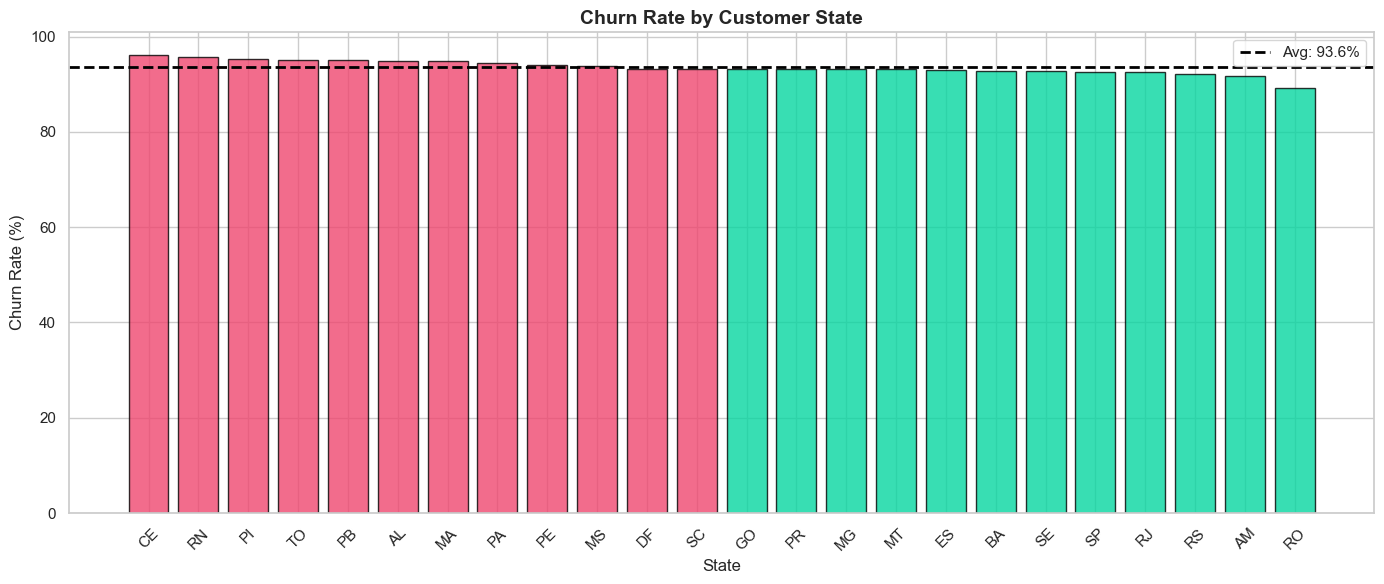


Top 5 Highest Churn States:
State  Churn Rate  Count
   CE    0.961115   1363
   RN    0.957031    512
   PI    0.953908    499
   TO    0.950980    306
   PB    0.950442    565

Top 5 Lowest Churn States:
State  Churn Rate  Count
   SP    0.925837  44321
   RJ    0.925616  13605
   RS    0.922218   5824
   AM    0.916667    156
   RO    0.892430    251


In [32]:
# Churn rate by state — top and bottom 10
state_churn = df.groupby('customer_state')['churn'].agg(['mean', 'count']).reset_index()
state_churn.columns = ['State', 'Churn Rate', 'Count']
state_churn = state_churn[state_churn['Count'] >= 100].sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#ef476f' if r > state_churn['Churn Rate'].median() else '#06d6a0'
          for r in state_churn['Churn Rate']]
bars = ax.bar(state_churn['State'], state_churn['Churn Rate'] * 100, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(state_churn['Churn Rate'].mean() * 100, color='black', linestyle='--', lw=2, label=f'Avg: {state_churn["Churn Rate"].mean()*100:.1f}%')
ax.set_title('Churn Rate by Customer State')
ax.set_xlabel('State')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nTop 5 Highest Churn States:')
print(state_churn.head(5).to_string(index=False))
print('\nTop 5 Lowest Churn States:')
print(state_churn.tail(5).to_string(index=False))

### 4.2 Payment Type vs. Churn

**H₀:** Churn is independent of the payment type.  
**H₁:** Different payment types have significantly different churn rates.

In [33]:
ct_pay = pd.crosstab(df['payment_type'], df['churn'])
chi2, p_val, dof, expected = chi2_contingency(ct_pay)
v = cramers_v(ct_pay)

print('=== Payment Type vs. Churn ===')
print(f'  Chi-square statistic: {chi2:.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  P-value:              {p_val:.4e}')
print(f"  Cramér's V:           {v:.4f}  → {interpret_cramers_v(v)} association")
decision = 'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05):    {decision}')
print()
print('Churn Rate by Payment Type:')
pay_churn = df.groupby('payment_type')['churn'].agg(['mean', 'count']).reset_index()
pay_churn.columns = ['Payment Type', 'Churn Rate', 'Count']
pay_churn['Churn Rate (%)'] = (pay_churn['Churn Rate'] * 100).round(2)
print(pay_churn.sort_values('Churn Rate', ascending=False).to_string(index=False))

=== Payment Type vs. Churn ===
  Chi-square statistic: 75.3195
  Degrees of freedom:   3
  P-value:              3.0948e-16
  Cramér's V:           0.0268  → Negligible association
  Decision (α=0.05):    REJECT H₀

Churn Rate by Payment Type:
Payment Type  Churn Rate  Count  Churn Rate (%)
  debit_card    0.945026   1528           94.50
 credit_card    0.930491  77501           93.05
      boleto    0.930014  20347           93.00
     voucher    0.901085   5621           90.11


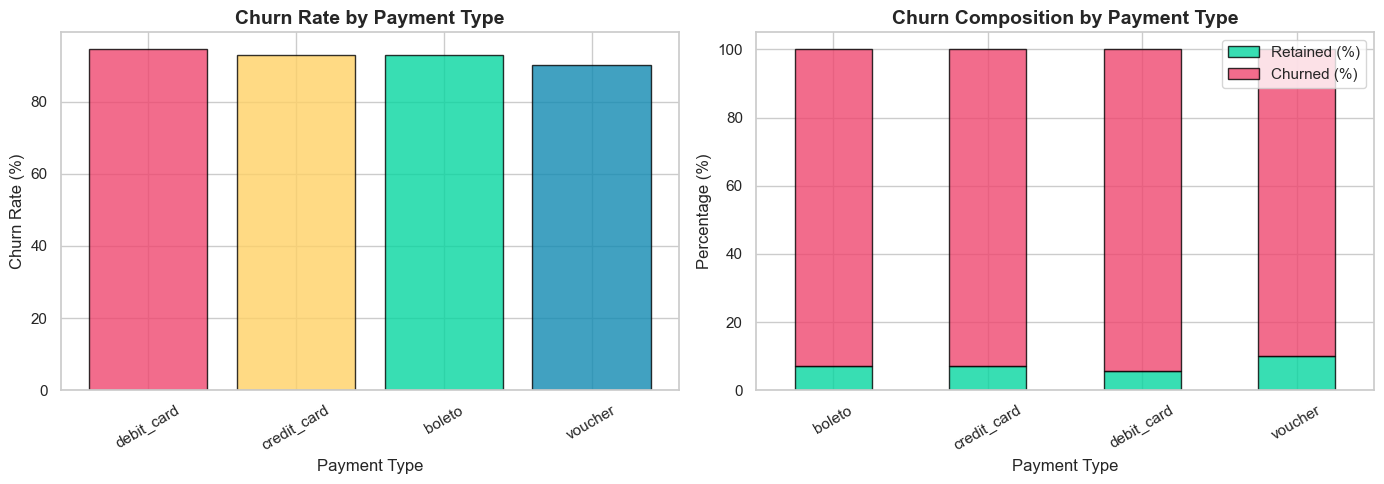

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate bar
pay_churn_sorted = pay_churn.dropna(subset=['Payment Type']).sort_values('Churn Rate', ascending=False)
axes[0].bar(pay_churn_sorted['Payment Type'], pay_churn_sorted['Churn Rate (%)'],
            color=['#ef476f', '#ffd166', '#06d6a0', '#118ab2'], edgecolor='black', alpha=0.8)
axes[0].set_title('Churn Rate by Payment Type')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# Volume stacked bar
ct_pay_pct = ct_pay.div(ct_pay.sum(axis=1), axis=0) * 100
ct_pay_pct.columns = ['Retained (%)', 'Churned (%)']
ct_pay_pct.plot(kind='bar', stacked=True,
                color=['#06d6a0', '#ef476f'], edgecolor='black', alpha=0.8, ax=axes[1])
axes[1].set_title('Churn Composition by Payment Type')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 4.3 Product Category vs. Churn

**H₀:** Churn is independent of the product category.  
**H₁:** Churn rate varies significantly across product categories.

In [35]:
cat_data = df.dropna(subset=['product_category_name_english'])

# Keep top 15 categories by volume for interpretability
top_cats = cat_data['product_category_name_english'].value_counts().head(15).index
cat_data_top = cat_data[cat_data['product_category_name_english'].isin(top_cats)]

ct_cat = pd.crosstab(cat_data_top['product_category_name_english'], cat_data_top['churn'])
chi2, p_val, dof, expected = chi2_contingency(ct_cat)
v = cramers_v(ct_cat)

print('=== Product Category vs. Churn (Top 15 categories) ===')
print(f'  Chi-square statistic: {chi2:.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  P-value:              {p_val:.4e}')
print(f"  Cramér's V:           {v:.4f}  → {interpret_cramers_v(v)} association")
decision = 'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'
print(f'  Decision (α=0.05):    {decision}')

=== Product Category vs. Churn (Top 15 categories) ===
  Chi-square statistic: 688.1149
  Degrees of freedom:   14
  P-value:              8.8678e-138
  Cramér's V:           0.0912  → Negligible association
  Decision (α=0.05):    REJECT H₀


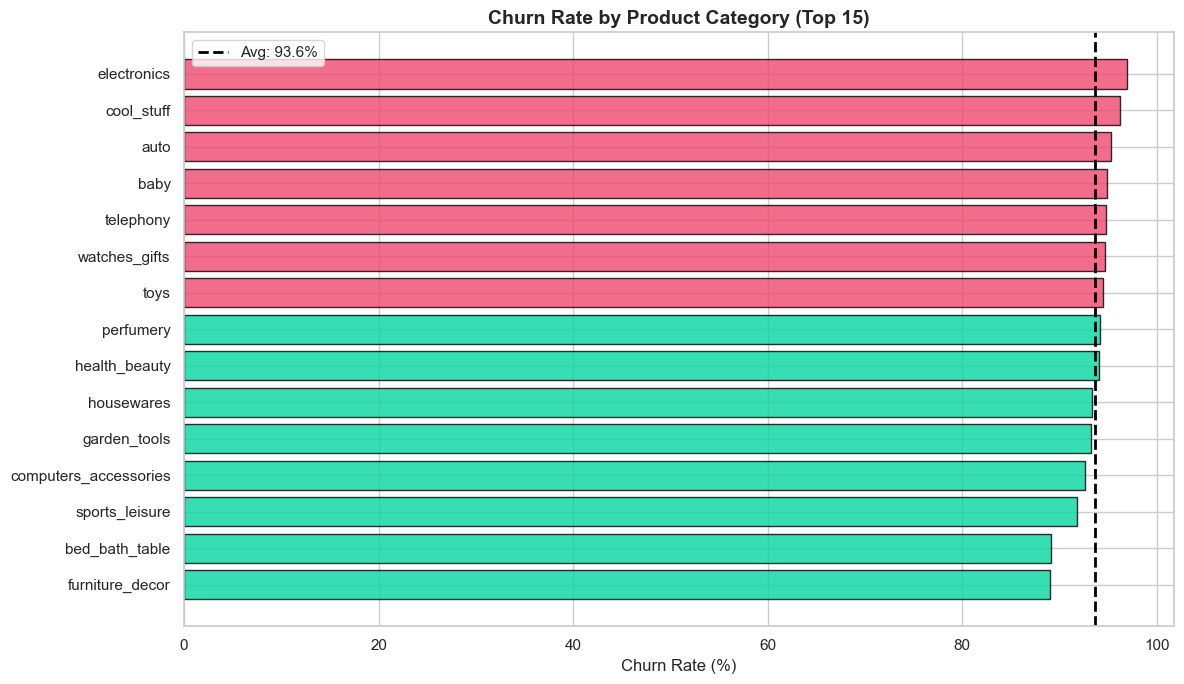

In [36]:
cat_churn = cat_data_top.groupby('product_category_name_english')['churn'].agg(['mean', 'count'])
cat_churn.columns = ['Churn Rate', 'Count']
cat_churn = cat_churn.sort_values('Churn Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#ef476f' if r > cat_churn['Churn Rate'].median() else '#06d6a0' for r in cat_churn['Churn Rate']]
ax.barh(cat_churn.index, cat_churn['Churn Rate'] * 100, color=colors, edgecolor='black', alpha=0.8)
ax.axvline(cat_churn['Churn Rate'].mean() * 100, color='black', linestyle='--', lw=2,
           label=f'Avg: {cat_churn["Churn Rate"].mean()*100:.1f}%')
ax.set_title('Churn Rate by Product Category (Top 15)')
ax.set_xlabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Categorical Variables Summary

In [37]:
cat_tests = [
    ('Customer State',    'customer_state',                   None),
    ('Payment Type',      'payment_type',                     None),
    ('Product Category',  'product_category_name_english',    top_cats),
]

cat_summary = []
for label, col, filter_vals in cat_tests:
    sub = df.dropna(subset=[col])
    if filter_vals is not None:
        sub = sub[sub[col].isin(filter_vals)]
    ct = pd.crosstab(sub[col], sub['churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    cat_summary.append({
        'Feature': label,
        'Chi-square': round(chi2, 2),
        'DoF': dof,
        'p-value': f'{p:.3e}',
        "Cramér's V": round(v, 4),
        'Association Strength': interpret_cramers_v(v),
        'Significant?': '✅ Yes' if p < 0.05 else '❌ No'
    })

cat_summary_df = pd.DataFrame(cat_summary)
print('Categorical Variables — Chi-square Test Summary')
print('=' * 90)
print(cat_summary_df.to_string(index=False))

Categorical Variables — Chi-square Test Summary
         Feature  Chi-square  DoF    p-value  Cramér's V Association Strength Significant?
  Customer State       78.29   26  3.841e-07      0.0273           Negligible        ✅ Yes
    Payment Type       75.32    3  3.095e-16      0.0268           Negligible        ✅ Yes
Product Category      688.11   14 8.868e-138      0.0912           Negligible        ✅ Yes


## 5. Multicollinearity Check (VIF)

Before logistic regression, we check for multicollinearity using the **Variance Inflation Factor (VIF)**.
- VIF = 1: No correlation with other features
- VIF 1–5: Moderate correlation (acceptable)
- VIF > 5: High multicollinearity (problematic — consider dropping or combining)

In [38]:
features = ['price', 'freight_value', 'payment_installments', 'review_score', 'delivery_delay_days', 'payment_value']
vif_data = df[features].dropna().copy()

vif_df = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(features))]
})
vif_df['VIF'] = vif_df['VIF'].round(2)
vif_df['Status'] = vif_df['VIF'].apply(lambda v: '✅ OK' if v <= 5 else '⚠️ High')
vif_df = vif_df.sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF) Results')
print('=' * 40)
print(vif_df.to_string(index=False))
print()
print('Note: Features with VIF > 5 may inflate logistic regression coefficients.')

Variance Inflation Factor (VIF) Results
             Feature  VIF Status
        review_score 3.77   ✅ OK
               price 3.38   ✅ OK
       payment_value 3.25   ✅ OK
       freight_value 2.96   ✅ OK
 delivery_delay_days 2.56   ✅ OK
payment_installments 2.20   ✅ OK

Note: Features with VIF > 5 may inflate logistic regression coefficients.


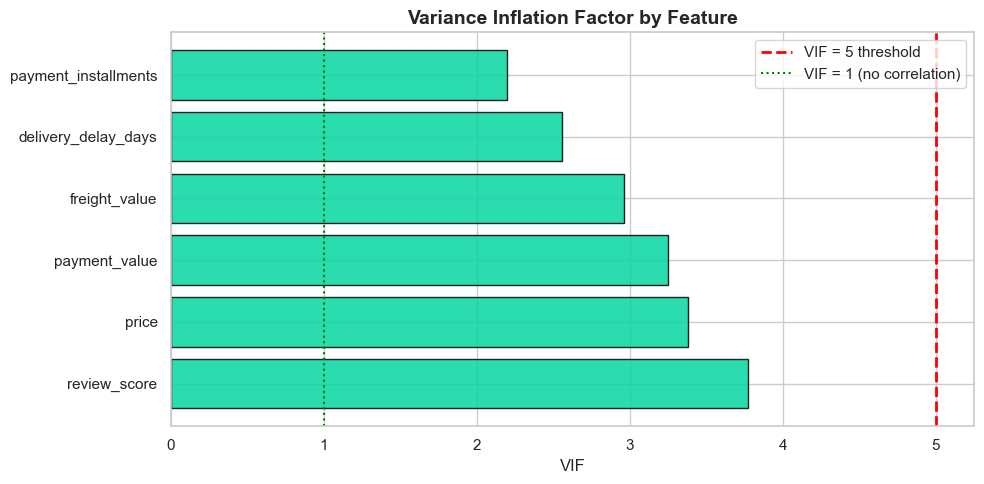

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ef476f' if v > 5 else '#06d6a0' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, edgecolor='black', alpha=0.85)
ax.axvline(5, color='red', linestyle='--', lw=2, label='VIF = 5 threshold')
ax.axvline(1, color='green', linestyle=':', lw=1.5, label='VIF = 1 (no correlation)')
ax.set_title('Variance Inflation Factor by Feature')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

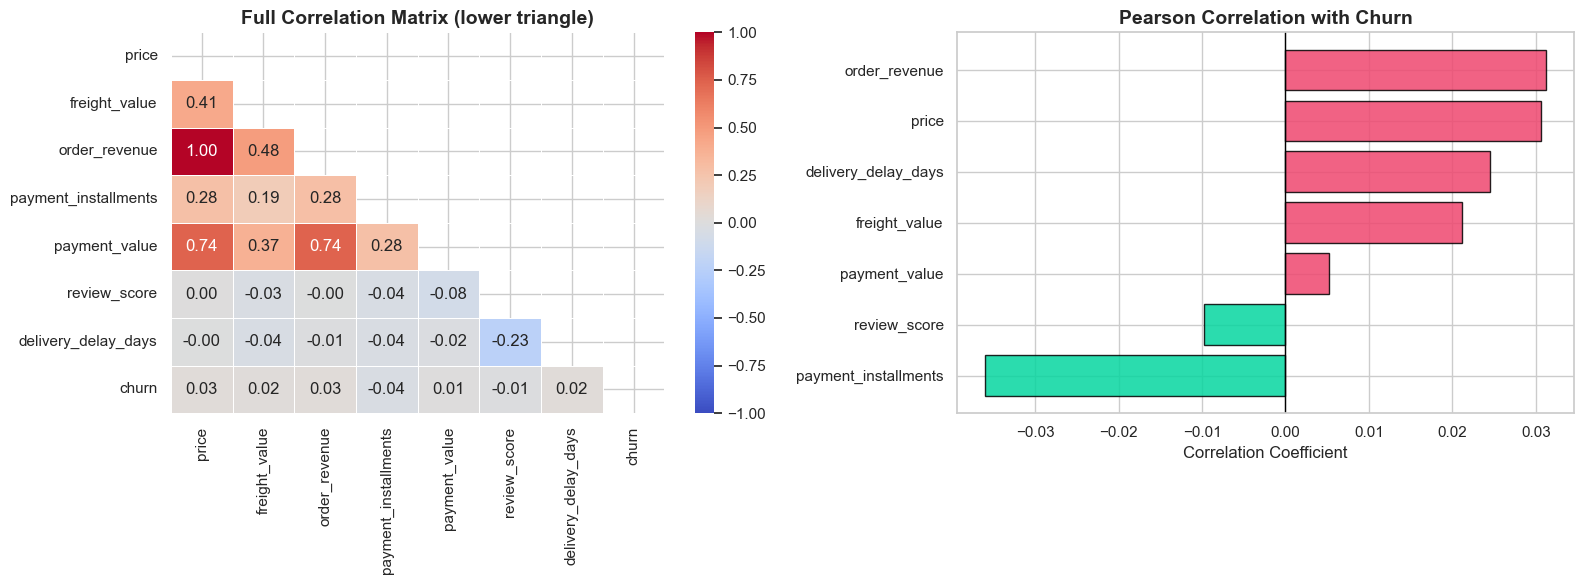


Correlation with Churn (sorted):
                       churn
order_revenue         0.0312
price                 0.0306
delivery_delay_days   0.0245
freight_value         0.0212
payment_value         0.0053
review_score         -0.0098
payment_installments -0.0360


In [40]:
num_cols = ['price', 'freight_value', 'order_revenue', 'payment_installments',
            'payment_value', 'review_score', 'delivery_delay_days', 'churn']
corr_matrix = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Full Correlation Matrix (lower triangle)')

# Churn-only bar chart
churn_corr = corr_matrix[['churn']].drop('churn').sort_values('churn', ascending=True)
colors = ['#ef476f' if v > 0 else '#06d6a0' for v in churn_corr['churn']]
axes[1].barh(churn_corr.index, churn_corr['churn'], color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Pearson Correlation with Churn')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

print('\nCorrelation with Churn (sorted):')
print(churn_corr.sort_values('churn', ascending=False).round(4))

## 7. Logistic Regression: Feature Importance & Odds Ratios

Logistic regression quantifies each feature's independent contribution to churn probability. We use:
- **Coefficients** — log-odds change per unit increase
- **Odds Ratios (OR)** = exp(coefficient)
  - OR > 1 → feature increases churn probability
  - OR < 1 → feature decreases churn probability
- **95% Confidence Intervals** — if CI excludes 1, the OR is statistically significant

In [41]:
# Use features without high multicollinearity (drop payment_value, order_revenue)
reg_features = ['price', 'freight_value', 'payment_installments', 'review_score', 'delivery_delay_days']
reg_data = df.dropna(subset=reg_features + ['churn']).copy()

X = reg_data[reg_features]
X = sm.add_constant(X)
y = reg_data['churn']

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=0)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:               104225
Model:                          Logit   Df Residuals:                   104219
Method:                           MLE   Df Model:                            5
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                0.008567
Time:                        21:48:09   Log-Likelihood:                -26419.
converged:                       True   LL-Null:                       -26648.
Covariance Type:            nonrobust   LLR p-value:                 1.851e-96
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.7621      0.047     59.358      0.000       2.671       2.853
price                    0.0014      0.000     11.388      0.000       0.001       0.002
freight_valu

In [42]:
# Odds Ratios with 95% CIs
odds_ratios = pd.DataFrame({
    'Feature': result.params.index,
    'Coefficient': result.params.values,
    'Odds Ratio': np.exp(result.params.values),
    'CI Lower (95%)': np.exp(result.conf_int()[0].values),
    'CI Upper (95%)': np.exp(result.conf_int()[1].values),
    'p-value': result.pvalues.values
})
odds_ratios = odds_ratios[odds_ratios['Feature'] != 'const'].round(4)
odds_ratios['Significant?'] = odds_ratios['p-value'].apply(lambda p: '✅ Yes' if p < 0.05 else '❌ No')
odds_ratios['Direction'] = odds_ratios['Odds Ratio'].apply(lambda x: '↑ Increases churn' if x > 1 else '↓ Decreases churn')
odds_ratios = odds_ratios.sort_values('Odds Ratio', ascending=False)

print('Logistic Regression — Odds Ratios Summary')
print('=' * 100)
print(odds_ratios.to_string(index=False))

Logistic Regression — Odds Ratios Summary
             Feature  Coefficient  Odds Ratio  CI Lower (95%)  CI Upper (95%)  p-value Significant?         Direction
 delivery_delay_days       0.0095      1.0096          1.0070          1.0121   0.0000        ✅ Yes ↑ Increases churn
       freight_value       0.0042      1.0042          1.0022          1.0063   0.0001        ✅ Yes ↑ Increases churn
               price       0.0014      1.0014          1.0011          1.0016   0.0000        ✅ Yes ↑ Increases churn
        review_score      -0.0218      0.9784          0.9606          0.9966   0.0204        ✅ Yes ↓ Decreases churn
payment_installments      -0.0680      0.9342          0.9265          0.9421   0.0000        ✅ Yes ↓ Decreases churn


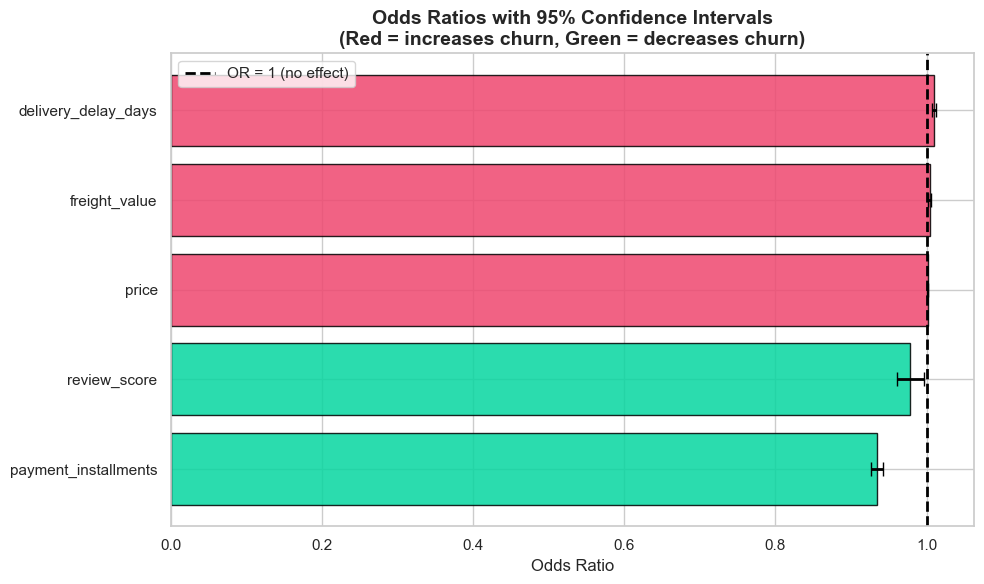

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

or_plot = odds_ratios.sort_values('Odds Ratio')
colors = ['#ef476f' if v > 1 else '#06d6a0' for v in or_plot['Odds Ratio']]

ax.barh(or_plot['Feature'], or_plot['Odds Ratio'], color=colors, edgecolor='black', alpha=0.85)
ax.errorbar(or_plot['Odds Ratio'], or_plot['Feature'],
            xerr=[or_plot['Odds Ratio'] - or_plot['CI Lower (95%)'],
                  or_plot['CI Upper (95%)'] - or_plot['Odds Ratio']],
            fmt='none', color='black', capsize=5, lw=2)

ax.axvline(1, color='black', linestyle='--', lw=2, label='OR = 1 (no effect)')
ax.set_title('Odds Ratios with 95% Confidence Intervals\n(Red = increases churn, Green = decreases churn)')
ax.set_xlabel('Odds Ratio')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary of Findings

> **Reminder:** With 100K+ records, statistical significance (p < 0.05) is almost guaranteed. **Effect size** (Cohen's d, Cramér's V, Odds Ratio) is the real measure of practical importance.

In [44]:
print('===================================================================')
print('            STATISTICAL ANALYSIS — SUMMARY OF FINDINGS')
print('===================================================================')
print()
print('CONTINUOUS VARIABLES (T-test + Mann-Whitney + Cohen\'s d)')
print('-------------------------------------------------------------------')
for _, row in summary_df.iterrows():
    print(f"  {row['Feature']:<30} Effect: {row['Effect Size']:<12} {row['Significant?']}")
print()
print('CATEGORICAL VARIABLES (Chi-square + Cramér\'s V)')
print('-------------------------------------------------------------------')
for _, row in cat_summary_df.iterrows():
    print(f"  {row['Feature']:<30} Association: {row['Association Strength']:<12} {row['Significant?']}")
print()
print('LOGISTIC REGRESSION — KEY DRIVERS OF CHURN')
print('-------------------------------------------------------------------')
for _, row in odds_ratios.iterrows():
    direction = '↑' if row['Odds Ratio'] > 1 else '↓'
    print(f"  {row['Feature']:<30} OR={row['Odds Ratio']:.4f}  {direction}  {row['Significant?']}")
print()
print('MULTICOLLINEARITY (VIF)')
print('-------------------------------------------------------------------')
for _, row in vif_df.iterrows():
    print(f"  {row['Feature']:<30} VIF={row['VIF']:.2f}   {row['Status']}")
print()
print('===================================================================')
print('→ These findings directly inform feature selection for ML models.')
print('===================================================================')

            STATISTICAL ANALYSIS — SUMMARY OF FINDINGS

CONTINUOUS VARIABLES (T-test + Mann-Whitney + Cohen's d)
-------------------------------------------------------------------
  Delivery Delay (days)          Effect: Negligible   ✅ Yes
  Review Score                   Effect: Negligible   ✅ Yes
  Price (R$)                     Effect: Negligible   ✅ Yes
  Freight Value (R$)             Effect: Negligible   ✅ Yes
  Payment Installments           Effect: Negligible   ✅ Yes

CATEGORICAL VARIABLES (Chi-square + Cramér's V)
-------------------------------------------------------------------
  Customer State                 Association: Negligible   ✅ Yes
  Payment Type                   Association: Negligible   ✅ Yes
  Product Category               Association: Negligible   ✅ Yes

LOGISTIC REGRESSION — KEY DRIVERS OF CHURN
-------------------------------------------------------------------
  delivery_delay_days            OR=1.0096  ↑  ✅ Yes
  freight_value                  OR=1.0042